
# Daily Climate Time Series Regression - LSTM - Jesus David Gelves Cajiao - 30000098650



In [1]:


# ============================================================================
# DBpedia Ontology Clasificacion LSTM - Kaggle Dataset
# Copyright:
#   Jesus David Gelves Cajiao - 3000098650
# ============================================================================
# Dependencias
# !pip install -q kagglehub[pandas-datasets]==0.3.5
# !pip install -q tensorflow scikit-learn matplotlib pandas --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [2]:

# Cargar el dataset con KaggleHub
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "DailyDelhiClimateTrain.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "sumanthvrao/daily-climate-time-series-data",
    file_path,
)

print("First 5 records:")
print(df.head())
print("Columns:", list(df.columns))


/tmp/ipython-input-3362194440.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.
First 5 records:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
Columns: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']


In [3]:
# Selección de columnas y limpieza
date_col_candidates = [c for c in df.columns if c.lower().startswith("date")]
assert len(date_col_candidates) >= 1, f"No se encontró columna de fecha en: {df.columns}"
date_col = date_col_candidates[0]

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.sort_values(date_col).set_index(date_col)

for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

rename_map = {}
for c in df.columns:
    lc = c.lower()
    if lc == "meantemp": rename_map[c] = "meantemp"
    if lc == "humidity": rename_map[c] = "humidity"
    if lc in ("wind_speed","windspeed","windsp"): rename_map[c] = "wind_speed"
    if lc in ("meanpressure","pressure","press"): rename_map[c] = "meanpressure"
if rename_map:
    df = df.rename(columns=rename_map)

df = df.interpolate(limit_direction="both")
print(df.info())
print(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB
None
               count         mean         std        min          25%  \
meantemp      1462.0    25.495521    7.348103   6.000000    18.857143   
humidity      1462.0    60.771702   16.769652  13.428571    50.375000   
wind_speed    1462.0     6.802209    4.561602   0.000000     3.475000   
meanpressure  1462.0  1011.104548  180.231668  -3.041667  1001.580357   

                      50%          75%          max  
meantemp        27.714286    31.305804    38.714286  
humidity        62.625000    72.218750   100.000000  
wind_speed       6.221667     9.238235    42

In [4]:

# Split temporal (Train / Val / Test)
W = 180
H = 30
TARGET = "meantemp"

assert TARGET in df.columns, f"No existe '{TARGET}' en {list(df.columns)}"

n = len(df)
i_train = int(n * 0.7)
i_val   = int(n * 0.85)

train = df.iloc[:i_train].copy()
val   = df.iloc[i_train:i_val].copy()
test  = df.iloc[i_val:].copy()

print("Split shapes:", train.shape, val.shape, test.shape)


Split shapes: (1023, 4) (219, 4) (220, 4)


In [5]:

# Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(train)
train_s = pd.DataFrame(scaler.transform(train), index=train.index, columns=train.columns)
val_s   = pd.DataFrame(scaler.transform(val),   index=val.index,   columns=val.columns)
test_s  = pd.DataFrame(scaler.transform(test),  index=test.index,  columns=test.columns)

train_s.head()


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,-2.084652,1.374502,-1.462377,1.045730
2013-01-02,-2.436417,1.812930,-0.834676,1.327448
2013-01-03,-2.467985,1.520645,-0.486422,1.441896
2013-01-04,-2.265044,0.604818,-1.202591,1.243813
2013-01-05,-2.625829,1.510902,-0.683017,1.155776


In [6]:
# Ventanas
def make_tf_dataset(df_s, target, W, H, batch, training=False, seed=42):
    """Crea ventanas al vuelo sin repetir; Keras inferirá los steps automáticamente."""
    import tensorflow as tf
    V = df_s.values.astype("float32")
    tix = df_s.columns.get_loc(target)
    y = V[W + H - 1 :, tix]

    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=V,
        targets=y,
        sequence_length=W,
        sampling_rate=1,
        sequence_stride=1,
        start_index=0,
        end_index=len(V) - H,
        shuffle=training,     # solo baraja en train
        batch_size=batch,
        seed=seed,
    )
    return ds.prefetch(tf.data.AUTOTUNE)


BATCH_SIZE = 64
ds_tr  = make_tf_dataset(train_s, TARGET, W, H, BATCH_SIZE, training=True)
ds_val = make_tf_dataset(val_s,   TARGET, W, H, BATCH_SIZE, training=False)
ds_te  = make_tf_dataset(test_s,  TARGET, W, H, BATCH_SIZE, training=False)


In [7]:
# Modelo LSTM
timesteps = W
features  = train_s.shape[1]

from tensorflow.keras import regularizers
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(W, train_s.shape[1]), dropout=0.3, recurrent_dropout=0.2),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(3e-4, clipnorm=1.0), loss="mse", metrics=["mae"])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 497ms/step - loss: 1.1244 - mae: 0.9425 - val_loss: 2.3063 - val_mae: 1.4859 - learning_rate: 3.0000e-04
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 535ms/step - loss: 0.7948 - mae: 0.7782 - val_loss: 1.7503 - val_mae: 1.2854 - learning_rate: 3.0000e-04
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - loss: 0.6888 - mae: 0.7107 - val_loss: 1.4179 - val_mae: 1.1476 - learning_rate: 3.0000e-04
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 543ms/step - loss: 0.5764 - mae: 0.6479 - val_loss: 1.0582 - val_mae: 0.9762 - learning_rate: 3.0000e-04
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 468ms/step - loss: 0.5066 - mae: 0.5875 - val_loss: 0.7041 - val_mae: 0.7700 - learning_rate: 3.0000e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 596ms/step - loss: 0.4563 - mae: 0.5517 - val_loss: 0.4361 - val_mae: 0.5691 - learning_rate: 3.0000e-04
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 458ms/step - loss: 0.3800 - mae: 0.5025 - val_loss: 0.3091 - val_mae: 0.4720 - lea

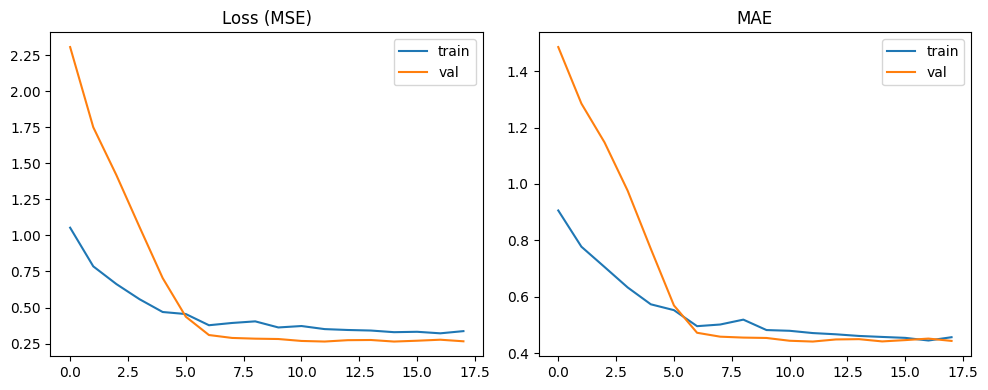

In [8]:
# Entrenamiento
EPOCHS = 30
STEPS_PER_EPOCH = 200
VAL_STEPS = 50

callbacks = [
    ModelCheckpoint("best_delhi.keras", save_best_only=True, monitor="val_loss", mode="min"),
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history = model.fit(
    ds_tr,
    validation_data=ds_val,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.title('Loss (MSE)'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(history.history['mae']);  plt.plot(history.history['val_mae']);  plt.title('MAE'); plt.legend(['train','val'])
plt.tight_layout(); plt.show()


Test MSE=1.1778 | RMSE=1.0853 | MAE=0.9690


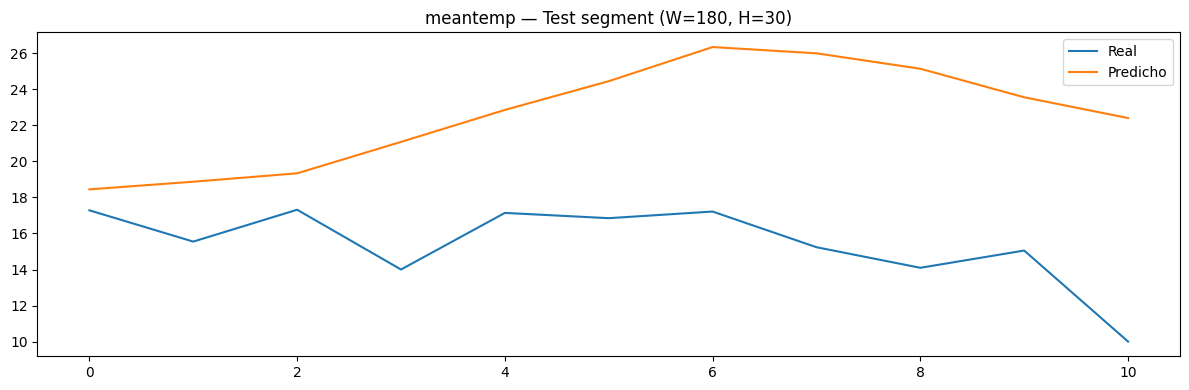

MAE final (val): 0.4409


In [10]:
#Evaluación y gráfico
tix = test_s.columns.get_loc(TARGET)
y_true_scaled = test_s.values.astype("float32")[W + H - 1 :, tix]
test_mse, test_mae = model.evaluate(ds_te, verbose=0)
y_pred_scaled = model.predict(ds_te, verbose=0).ravel()

mu    = scaler.mean_[train.columns.get_loc(TARGET)]
sigma = (scaler.var_[train.columns.get_loc(TARGET)]) ** 0.5
y_true = y_true_scaled * sigma + mu
y_pred = y_pred_scaled * sigma + mu

rmse = float(np.sqrt(test_mse))
print(f"Test MSE={test_mse:.4f} | RMSE={rmse:.4f} | MAE={test_mae:.4f}")

N = min(300, len(y_true))
plt.figure(figsize=(12,4))
plt.plot(y_true[:N], label="Real")
plt.plot(y_pred[:N], label="Predicho")
plt.title(f"{TARGET} — Test segment (W={W}, H={H})")
plt.legend(); plt.tight_layout(); plt.show()

print(f"MAE final (val): {min(history.history['val_mae']):.4f}")